## 2.1 理论计算题（线性代数）

已知：
- 向量 $a = [2, -1, 3]^\top$
- 向量 $b = [1, 4, -2]^\top$
- 矩阵 $A = \begin{bmatrix}1 & 0 & 2 \\ -1 & 3 & 1\end{bmatrix}$
- 矩阵 $B = \begin{bmatrix}2 & 1 \\ 0 & -1 \\ 3 & 2\end{bmatrix}$

### 1. 向量点积 $a \cdot b$
$$a \cdot b = 2\times1 + (-1)\times4 + 3\times(-2) = 2 - 4 - 6 = -8$$

### 2. 矩阵乘法 $A \times B$
$$A \times B = \begin{bmatrix}1\times2+0\times0+2\times3 & 1\times1+0\times(-1)+2\times2 \\ -1\times2+3\times0+1\times3 & -1\times1+3\times(-1)+1\times2\end{bmatrix} = \begin{bmatrix}8 & 5 \\ 1 & -2\end{bmatrix}$$
结果形状：**2×2**

### 3. 向量 $a$ 的 Frobenius 范数
$$\|a\|_F = \sqrt{2^2 + (-1)^2 + 3^2} = \sqrt{4+1+9} = \sqrt{14} \approx 3.7417$$

In [ ]:

import numpy as np

# 1. 创建3×4标准正态随机矩阵X
X = np.random.randn(3, 4)
print("X =\n", X)

# 2. 创建4×2全1矩阵Y
Y = np.ones((4, 2))
print("\nY =\n", Y)

# 3. 矩阵乘法Z = X × Y
Z = np.dot(X, Y)
print("\nZ =\n", Z)

# 4. 输出指定元素
print("\nZ[0, 1] =", Z[0, 1])  # 第一行第二列
print("Z[1, :] =", Z[1, :])   # 第二行所有元素

# 5. 计算Z的Frobenius范数
fro_Z = np.linalg.norm(Z, 'fro')
print("\nZ的Frobenius范数 =", fro_Z)

X =
 [[-1.85482869  0.70981328 -0.63825254 -1.22555912]
 [ 1.36308811  0.37360897  1.17202616  0.45246241]
 [-1.77533249  0.1999679   0.15354618 -0.19431599]]

Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z =
 [[-3.00882708 -3.00882708]
 [ 3.36118564  3.36118564]
 [-1.61613441 -1.61613441]]

Z[0, 1] = -3.0088270772364942
Z[1, :] = [3.36118564 3.36118564]

Z的Frobenius范数 = 6.776798615359152


## 3.1 理论计算题（贝叶斯公式）

已知：
- 患病率 $P(A) = 0.1\% = 0.001$
- 灵敏度 $P(+|A) = 99\% = 0.99$
- 假阳性率 $P(+|\neg A) = 2\% = 0.02$

求：$P(A|+)$（检测阳性时真正患病概率）

### 贝叶斯公式：
$$P(A|+) = \frac{P(+|A)P(A)}{P(+|A)P(A) + P(+|\neg A)P(\neg A)}$$

### 计算：
$$P(A|+) = \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999} = \frac{0.00099}{0.00099 + 0.01998} = \frac{0.00099}{0.02097} \approx 0.0472$$

**结果：约 4.72%**

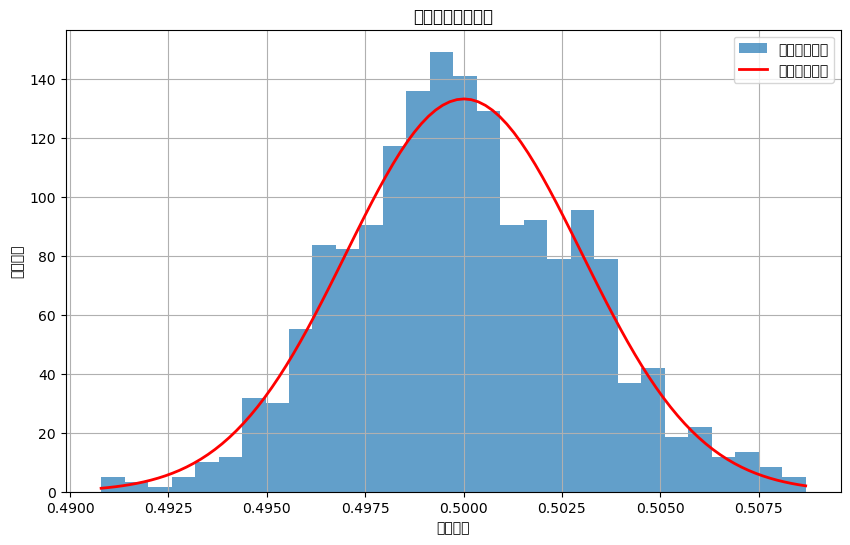

实际方差 = 0.000009
理论方差 = 0.000008


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. 生成数据
n = 10000  # 每次样本数
m = 1000   # 重复次数
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

# 2. 绘制直方图与正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')

# 理论正态分布
mu, std = np.mean(means), np.std(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证')
plt.legend()
plt.grid(True)
plt.show()

# 3. 计算实际方差
var_actual = np.var(means)
print(f"实际方差 = {var_actual:.6f}")
print(f"理论方差 = {(1/12)/n:.6f}")

## 4.1 理论计算题（导数与梯度）

已知：$z = (w_1x_1 + w_2x_2 - y)^2$，$x_1=2, x_2=1, y=3$

### 1. 偏导数表达式
令 $u = w_1x_1 + w_2x_2 - y$，则 $z = u^2$

$$\frac{\partial z}{\partial w_1} = 2u \cdot x_1 = 2x_1(w_1x_1 + w_2x_2 - y)$$
$$\frac{\partial z}{\partial w_2} = 2u \cdot x_2 = 2x_2(w_1x_1 + w_2x_2 - y)$$

代入常数：
$$\frac{\partial z}{\partial w_1} = 4(2w_1 + w_2 - 3)$$
$$\frac{\partial z}{\partial w_2} = 2(2w_1 + w_2 - 3)$$

### 2. 当 $w_1=0.5, w_2=1$ 时的梯度
$$2w_1 + w_2 - 3 = 1 + 1 - 3 = -1$$

$$\frac{\partial z}{\partial w_1} = 4\times(-1) = -4$$
$$\frac{\partial z}{\partial w_2} = 2\times(-1) = -2$$

**梯度：$(-4, -2)$**

In [14]:
# 1. 手动前向传播 + 手动反向传播（链式法则）
x = 2
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b

print("==== 手动前向结果 ====")
print(f"a = x * w1 = {a}")
print(f"b = a + w2 = {b}")
print(f"L = {L}\n")

# 手动反向传播（链式法则）
# L = b = a + w2 = x*w1 + w2
# dL/dw1 = x
# dL/dw2 = 1

dL_dw1 = x
dL_dw2 = 1

print("==== 手动梯度（链式法则）====")
print(f"dL/dw1 = {dL_dw1}")
print(f"dL/dw2 = {dL_dw2}\n")

# 2. PyTorch 自动微分验证
import torch

# 定义需要求梯度的张量
x = torch.tensor(2.0, requires_grad=False)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 前向传播
a = x * w1
b = a + w2
L = b

# 反向传播
L.backward()

print("==== PyTorch 自动微分结果 ====")
print(f"w1.grad = {w1.grad.item()}")
print(f"w2.grad = {w2.grad.item()}")

==== 手动前向结果 ====
a = x * w1 = 3.0
b = a + w2 = 3.5
L = 3.5

==== 手动梯度（链式法则）====
dL/dw1 = 2
dL/dw2 = 1

==== PyTorch 自动微分结果 ====
w1.grad = 2.0
w2.grad = 1.0


## 5.1 理论计算题（线性回归梯度）

线性回归：$y = wx + b$
均方误差损失：$L = \frac{1}{n}\sum_{i=1}^n(y_i - (wx_i + b))^2$

### 损失对 $w$ 的偏导数
$$\frac{\partial L}{\partial w} = \frac{2}{n}\sum_{i=1}^n -x_i(y_i - wx_i - b) = -\frac{2}{n}\sum_{i=1}^n x_i(y_i - \hat{y}_i)$$

### 损失对 $b$ 的偏导数
$$\frac{\partial L}{\partial b} = \frac{2}{n}\sum_{i=1}^n -(y_i - wx_i - b) = -\frac{2}{n}\sum_{i=1}^n (y_i - \hat{y}_i)$$

In [ ]:

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target  # (1797,)

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. One-hot编码
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# 3. Softmax与交叉熵
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 4. 训练参数
input_dim = 64
num_classes = 10
lr = 0.1
epochs = 50
batch_size = 32

# 初始化参数
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros(num_classes)

# 训练
train_losses = []
for epoch in range(epochs):
    # 小批量梯度下降
    indices = np.random.permutation(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_indices = indices[i:i+batch_size]
        X_batch = X_train[batch_indices]
        y_batch = y_train_onehot[batch_indices]

        # 前向
        z = X_batch @ W + b
        y_pred = softmax(z)

        # 反向
        dz = y_pred - y_batch
        dW = X_batch.T @ dz / len(X_batch)
        db = np.mean(dz, axis=0)

        # 更新
        W -= lr * dW
        b -= lr * db

    # 记录损失
    z_train = X_train @ W + b
    y_pred_train = softmax(z_train)
    loss = cross_entropy(y_pred_train, y_train_onehot)
    train_losses.append(loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

# 5. 测试准确率
z_test = X_test @ W + b
y_pred_test = softmax(z_test)
acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test)
print(f"\n测试集准确率: {acc:.4f}")

Epoch 10/50, Loss: 0.4672
Epoch 20/50, Loss: 0.0890
Epoch 30/50, Loss: 0.0691
Epoch 40/50, Loss: 0.0034
Epoch 50/50, Loss: 0.0002

测试集准确率: 0.9694


## 6.1 理论计算题（正态分布最大似然估计）

样本 $x_1,...,x_n \sim N(\mu, \sigma^2)$

### 1. 似然函数
$$L(\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x_i-\mu)^2}{2\sigma^2}}$$

### 2. 证明 $\hat{\mu} = \frac{1}{n}\sum x_i$
取对数：
$$\ln L = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln\sigma^2 - \frac{1}{2\sigma^2}\sum(x_i-\mu)^2$$

对 $\mu$ 求导并令为0：
$$\frac{\partial \ln L}{\partial \mu} = \frac{1}{\sigma^2}\sum(x_i-\mu) = 0 \implies \sum x_i - n\mu = 0 \implies \hat{\mu} = \frac{1}{n}\sum x_i$$

### 3. 证明 $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\hat{\mu})^2$
对 $\sigma^2$ 求导并令为0：
$$\frac{\partial \ln L}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum(x_i-\mu)^2 = 0$$

$$\implies -n(\sigma^2) + \sum(x_i-\mu)^2 = 0 \implies \hat{\sigma}^2 = \frac{1}{n}\sum(x_i-\hat{\mu})^2$$

Iteration 100, Loss: 0.0304
Iteration 200, Loss: 0.0200
Iteration 300, Loss: 0.0159
Iteration 400, Loss: 0.0137
Iteration 500, Loss: 0.0121
Iteration 600, Loss: 0.0111
Iteration 700, Loss: 0.0102
Iteration 800, Loss: 0.0095
Iteration 900, Loss: 0.0090
Iteration 1000, Loss: 0.0085

测试集准确率: 1.0000


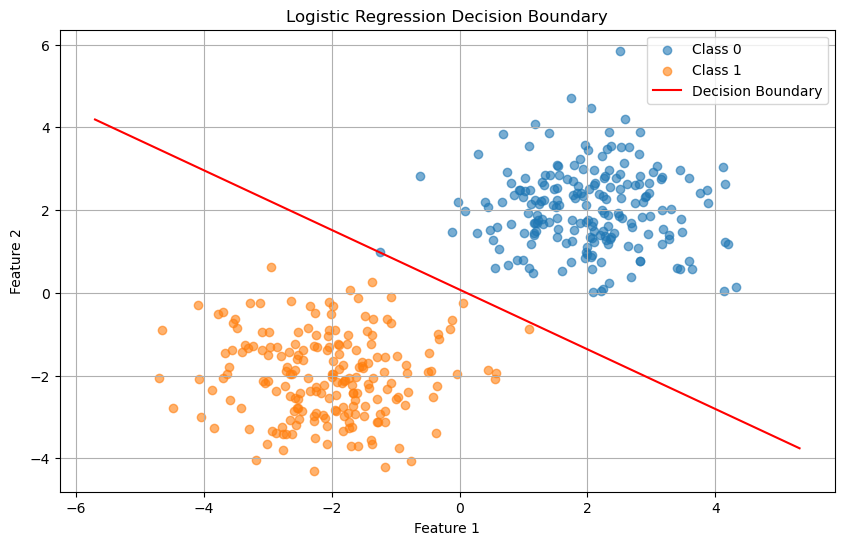

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. 生成线性可分数据
np.random.seed(42)
n_samples = 200
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
X2 = np.random.randn(n_samples, 2) + np.array([-2, -2])
X = np.vstack([X1, X2])
y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])

# 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Sigmoid与交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

# 3. 梯度下降训练
lr = 0.1
iterations = 1000
w = np.random.randn(2) * 0.01
b = 0.0

losses = []
for i in range(iterations):
    z = X_train @ w + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y_train)
    losses.append(loss)

    # 梯度
    dz = y_pred - y_train
    dw = X_train.T @ dz / len(X_train)
    db = np.mean(dz)

    # 更新
    w -= lr * dw
    b -= lr * db

    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1}, Loss: {loss:.4f}")

# 4. 测试与可视化
y_pred_test = sigmoid(X_test @ w + b)
y_pred_test_class = (y_pred_test > 0.5).astype(int)
acc = np.mean(y_pred_test_class == y_test)
print(f"\n测试集准确率: {acc:.4f}")

# 绘制决策边界
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], label='Class 0', alpha=0.6)
plt.scatter(X[y==1, 0], X[y==1, 1], label='Class 1', alpha=0.6)

# 决策边界线
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
xx = np.linspace(x_min, x_max, 100)
yy = -(w[0] * xx + b) / w[1]
plt.plot(xx, yy, 'r-', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()